# Fairness Analysis

This notebook evaluates the trained recruitment model using two fairness
definitions: demographic parity and equal opportunity.

Demographic parity compares overall hiring rates across gender groups.
Equal opportunity compares true positive rates among candidates classified
as qualified.

Because the dataset does not provide an independent ground truth
qualification label, qualification is operationalised using a transparent
proxy based on four job related assessment scores: Skill, Aptitude,
Technical, and Interview scores.

## Loading Model Predictions

The model predictions generated during model training are loaded for the
fairness analysis. The protected attribute, `Gender`, is retained for
group based fairness evaluation.

In [3]:
import pandas as pd

results = pd.read_csv("../result/model_predictions.csv", index_col=0)

results.head()

,Age,Education_Level,Experience_Years,Skill_Score,Aptitude_Test_Score,Technical_Test_Score,Communication_Score,Certifications_Count,Previous_Companies,Interview_Score,Location,Job_Role_Applied,Expected_Salary,Actual_Hiring_Decision,Predicted_Hiring_Decision,Gender
41730,21,Bachelors,14,86,73,79,8,1.0,4,54,Rural,HR Executive,144879,1,1,Male
78138,43,High School,13,13,24,48,46,0.0,1,0,Semi-Urban,Manager,22572,0,0,Male
112634,22,Bachelors,2,34,40,88,1,9.0,6,43,Urban,ML Engineer,101647,0,0,Male
76022,26,High School,11,84,18,27,69,4.0,5,72,Semi-Urban,HR Executive,78336,0,0,Female
64694,38,High School,9,28,43,54,67,7.0,5,69,Semi-Urban,HR Executive,58113,0,0,Female


## Defining Qualification

A qualification score is calculated as the mean of four job related
assessment scores: Skill, Aptitude, Technical, and Interview.

Candidates with a score above 60 are classified as qualified. The threshold
is based on the observed separation in the dataset, where rejected candidates
have a maximum score of 60 while hired candidates begin at 58.75.

This qualification label is a proxy derived from the dataset and should not
be interpreted as an objective measure of real world candidate quality.

In [4]:
results["Qualification_Score"] = (
    results["Skill_Score"]
    + results["Aptitude_Test_Score"]
    + results["Technical_Test_Score"]
    + results["Interview_Score"]
) / 4

results["Qualified"] = (
    results["Qualification_Score"] > 60
).astype(int)

results[[
    "Qualification_Score",
    "Qualified"
]].head()

,Qualification_Score,Qualified
41730,73.00,1
78138,21.25,0
112634,51.25,0
76022,50.25,0
64694,48.50,0


## Qualification Distribution by Gender

The distribution of qualified candidates is examined across gender groups
before calculating equal opportunity.

In [5]:
pd.crosstab(
    results["Gender"],
    results["Qualified"],
    margins=True
)

Qualified,0,1,All
Gender,,,
Female,6382,1993,8375
Male,10999,3456,14455
Other,882,283,1165
All,18263,5732,23995


## Demographic Parity

Demographic parity evaluates whether the model produces similar hiring rates
across gender groups.

For each gender group, the predicted hiring rate is calculated as the
proportion of candidates predicted to be hired within that group.

In [6]:
demographic_parity = pd.crosstab(
    results["Gender"],
    results["Predicted_Hiring_Decision"],
    normalize="index"
)

demographic_parity

Predicted_Hiring_Decision,0,1
Gender,,
Female,0.742687,0.257313
Male,0.741819,0.258181
Other,0.742489,0.257511


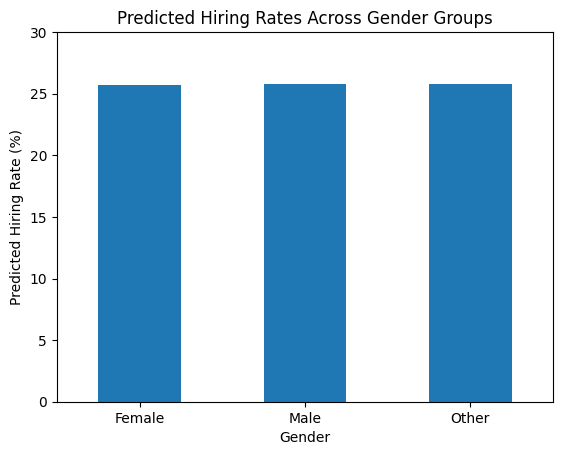

In [7]:
import matplotlib.pyplot as plt

dp_rates = demographic_parity[1] * 100

dp_rates.plot(kind="bar")

plt.title("Predicted Hiring Rates Across Gender Groups")
plt.xlabel("Gender")
plt.ylabel("Predicted Hiring Rate (%)")
plt.xticks(rotation=0)
plt.ylim(0, 30)

plt.show()

## Equal Opportunity

Equal opportunity evaluates whether qualified candidates have similar true
positive rates across gender groups.

The true positive rate (TPR) is calculated as the proportion of qualified
candidates who are predicted as hired by the model.

In [8]:
qualified_candidates = results[results["Qualified"] == 1]

equal_opportunity = pd.crosstab(
    qualified_candidates["Gender"],
    qualified_candidates["Predicted_Hiring_Decision"],
    normalize="index"
)

equal_opportunity

Predicted_Hiring_Decision,1
Gender,
Female,1.0
Male,1.0
Other,1.0


In [9]:
eo_rates = equal_opportunity[1]

eo_difference = eo_rates.max() - eo_rates.min()

eo_difference

np.float64(0.0)

In [10]:
dp_rates = demographic_parity[1]

dp_difference = dp_rates.max() - dp_rates.min()

dp_difference

np.float64(0.0008671275239162113)

In [11]:
fairness_comparison = pd.DataFrame({
    "Metric": [
        "Demographic Parity",
        "Equal Opportunity"
    ],
    "Female Rate": [
        demographic_parity.loc["Female", 1],
        equal_opportunity.loc["Female", 1]
    ],
    "Male Rate": [
        demographic_parity.loc["Male", 1],
        equal_opportunity.loc["Male", 1]
    ],
    "Other Rate": [
        demographic_parity.loc["Other", 1],
        equal_opportunity.loc["Other", 1]
    ],
    "Max-Min Difference": [
        dp_difference,
        eo_difference
    ]
})

fairness_comparison

,Metric,Female Rate,Male Rate,Other Rate,Max-Min Difference
0,Demographic Parity,0.257313,0.258181,0.257511,0.000867
1,Equal Opportunity,1.000000,1.000000,1.000000,0.000000


## Interpretation of Fairness Results

The two fairness definitions produce similar results for the evaluated model
on this dataset. Under demographic parity, the maximum difference in predicted
hiring rates across gender groups is 0.000867, equivalent to approximately
0.087 percentage points. This indicates very similar overall predicted hiring
rates across the groups.

Under equal opportunity, the true positive rate is 1.00 for Female, Male,
and Other candidates classified as qualified using the qualification proxy.
Therefore, the maximum TPR difference is 0 percentage points.

These results show that the choice of fairness definition does not produce
substantially different conclusions for this particular model and dataset.
However, this finding should not be generalised to recruitment systems more
broadly. Equal opportunity depends on the constructed qualification proxy,
and the proxy itself is derived from the same dataset. The results therefore
indicate fairness under the operational definitions used in this study,
rather than establishing that the recruitment system is universally fair.

## Limitations

Several limitations should be considered when interpreting the fairness
results.

First, the dataset does not contain an independent ground truth label for
whether a candidate is genuinely qualified for a position. Therefore,
qualification was operationalised using a proxy based on the mean of Skill,
Aptitude, Technical, and Interview scores. This proxy is data derived and
may not fully represent real world candidate qualification.

Second, the qualification threshold of 60 was selected based on the observed
separation between the dataset's hiring decisions and qualification scores.
This makes the threshold data informed rather than an independently
validated recruitment standard.

Third, the analysis uses a single logistic regression model and one
train test split. Different models, datasets, or train-test splits could
produce different fairness measurements.

Finally, the analysis evaluates gender as the protected attribute and does
not examine other potentially relevant attributes or interactions between
multiple protected characteristics.

## Conclusion

This study compared demographic parity and equal opportunity when evaluating
gender fairness in an AI based recruitment model.

The logistic regression model achieved an accuracy of approximately 98.55%
on the test set. Under demographic parity, the predicted hiring rates were
25.731% for Female candidates, 25.818% for Male candidates, and 25.751% for
Other candidates. The maximum difference between groups was approximately
0.087 percentage points.

Under equal opportunity, the true positive rate was 100% for all three gender
groups using the qualification proxy, resulting in a maximum difference of
0 percentage points.

Therefore, the two fairness definitions produced similar conclusions for
this particular dataset and model despite measuring different aspects of
fairness. Demographic parity evaluates overall predicted hiring rates,
whereas equal opportunity evaluates the treatment of candidates classified
as qualified.

The results demonstrate that fairness measurements depend on how fairness
and qualification are operationalised. However, they do not establish that
one definition is universally preferable or that the findings apply to
real world recruitment systems. Further research using independent
qualification labels, multiple models, and additional protected attributes
would be necessary to assess how robust these findings are.